In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import glob
import hvplot.xarray
import seaborn as sns
import numpy.ma as ma
import scipy

In [2]:
import pandas as pd

### some functions

In [3]:
from statsmodels.distributions.empirical_distribution import ECDF

In [4]:
brbg = LinearSegmentedColormap.from_list('brbg', matplotlib.colormaps["BrBG"](np.arange(0, 1.1, .1)), N = 11)
pugy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.5, .04)), 
                matplotlib.colormaps["PiYG_r"](np.arange(0.5, 0.85, .04))]), N = 10)

brbl = LinearSegmentedColormap.from_list('brbl', np.concatenate([matplotlib.colormaps["BrBG"](np.arange(0, 0.6, .1)), 
                matplotlib.colormaps["RdBu"](np.arange(0.5, 1.1, .1))]), N = 11)

bupu = LinearSegmentedColormap.from_list('bupu', matplotlib.colormaps["BuPu"](np.arange(0, 1.1, .1)), N = 10)
oranges = LinearSegmentedColormap.from_list('oranges', matplotlib.colormaps["Oranges"](np.arange(0, 1.1, .1)), N = 9)
reds = LinearSegmentedColormap.from_list('reds', matplotlib.colormaps["Reds"](np.arange(0, 1.1, .1)), N = 11)

In [5]:
def ecdf_func(cmip, obs):
    if np.isnan(cmip).all():
        return(np.nan)
    return (ECDF(cmip)(obs))

def ecdf_xr(cmip, obs):       
    return xr.apply_ufunc(ecdf_func, cmip, obs, 
                          input_core_dims = (["model_variant"], []), 
                          dask = "allowed", 
                          vectorize = True, ## required when function can only take 1D array
                         )

In [6]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "white", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    if na_col is not None:
        ax.set_facecolor(na_col)
    else: 
        ax.set_facecolor(plt.get_cmap(CMAP)(0))
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = 'white')
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.7, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 16)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.7, location = "bottom")

    return(p)

### Read in data

In [7]:
start = 1980
end = 2019

In [8]:
obs_trend = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
obs_stat = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")

In [9]:
## find cmip simulations with necessary criteria, read in data
cmip_files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
cmip_trends = []
for f in cmip_files:
    cmip_trends.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))

cmip_trends = xr.concat(cmip_trends, dim = "model_variant")

In [10]:
cmip_files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-2023_p095_trend.nc"))
cmip_trends2023 = []
for f in cmip_files:
    cmip_trends2023.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
cmip_trends2023 = xr.concat(cmip_trends2023, dim = "model_variant")

In [11]:
files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(end)+"_stats.nc"))
cmip_stat = []
for f in files:
    cmip_stat.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
cmip_stat = xr.concat(cmip_stat, dim = "model_variant")

In [12]:
files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-2023_stats.nc"))
cmip_stat2023 = []
for f in files:
    cmip_stat2023.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
cmip_stat2023 = xr.concat(cmip_stat2023, dim = "model_variant")

In [13]:
sim_table = pd.read_csv("../processed_data/simulation_table_mon_pr.csv")
sim_table = sim_table[(sim_table['start_date'] <= "1930-01") & (sim_table['end_date'] >= "2019-12")]
sim_table_onevar = sim_table.sort_values("variant").groupby("model").first().reset_index()
onevar_model_keys = list(sim_table_onevar["model"]+"_"+sim_table_onevar["variant"])

In [14]:
obs_trend_std = (obs_trend.sel(predictions = "coeff").value*(end-start+1))/obs_stat.p95*100
cmip_trend_std = (cmip_trends.sel(predictions = "coeff").value*(end-start+1))/cmip_stat.p95*100

cmip_trend_std = cmip_trend_std.sel(model_variant = onevar_model_keys)

In [15]:
cmip_trend2023_std = cmip_trends2023.sel(
    model_variant = onevar_model_keys).sel(predictions = "coeff").value*(2023-start+1)/cmip_stat.p95*100

### Quantile Regression Figure

In [16]:
obs_ds = xr.open_dataset("../processed_data/GPCC/gpcc_mon_precip_5x5.nc").sel(time = slice("1980-01-01", "2019-12-31"))

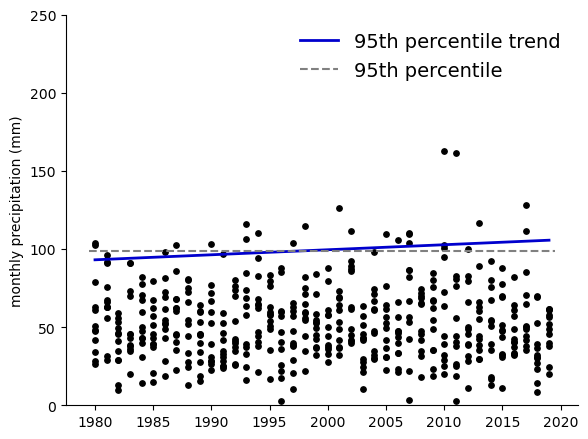

In [63]:
fig, ax = plt.subplots(1, 1, figsize = (6, 4.5))

k = 50
j = 10

ax.scatter(obs_ds.time.dt.year, 
           obs_ds.sel(lon = j, lat = k, method = "nearest").pr, s = 15, c = "black")

a = obs_trend.sel(lon = j, lat = k, method = "nearest").sel(predictions = "coeff").value.values
b = obs_trend.sel(lon = j, lat = k, method = "nearest").sel(predictions = "intercept").value.values
y1 = obs_ds.time.dt.year*a + b
ax.plot(obs_ds.time.dt.year[np.arange(0, len(y1), 10)], y1[np.arange(0, len(y1), 10)], 
        linewidth = 2, color = "mediumblue", label = "95th percentile trend")
ax.set(ylabel = "monthly precipitation (mm)", ylim = (0, 250))
ax.hlines(obs_stat.sel(lon = j, lat = k, method = "nearest").p95, 1979.5, 2019.5, 
          color = "gray", linestyle = "dashed", label = "95th percentile")
plt.legend(frameon=False, fontsize = 14)
plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("../figures/quantile_regression_monthly.pdf")

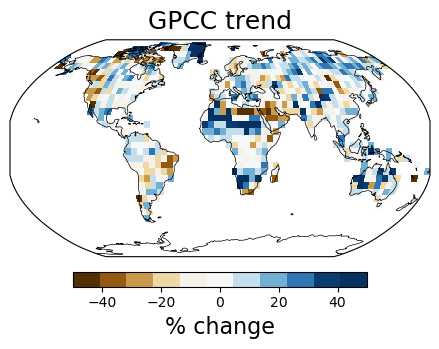

In [18]:
## create trend maps for observations
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("GPCC trend", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(obs_trend_std, 
             obs_trend.lon, obs_trend.lat, ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/gpcc_trend_map.pdf")

In [19]:
gpcp_trend = xr.open_dataset("../processed_data/gpcp_trends/gpcp_mon_1980-2019_5x5_p095_trend.nc")
gpcp_stat = xr.open_dataset("../processed_data/gpcp_stats/gpcp_mon_1980-2019_5x5_stats.nc")
gpcp_trend_std = (gpcp_trend.sel(predictions = "coeff").value*40)/gpcp_stat.p95*100

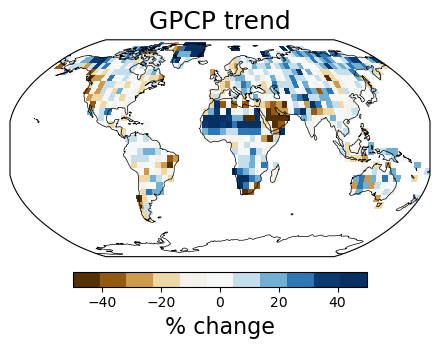

In [20]:
## create trend maps for observations
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("GPCP trend", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(gpcp_trend_std, 
             gpcp_trend.lon, gpcp_trend.lat, ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/gpcp_trend_map.pdf")


In [40]:
print("positive trends:", (obs_trend_std > 0).sum().values/713)

positive trends: 0.5371669004207573


In [51]:
a = obs_trend_std.sel(lat = slice(-58.75, 88.75)).values.ravel()
np.corrcoef(a[~np.isnan(a)],
            cmip_trend_std.mean(dim = "model_variant").values.ravel()[~np.isnan(a)])[0,1]

np.float64(0.1357511563226208)

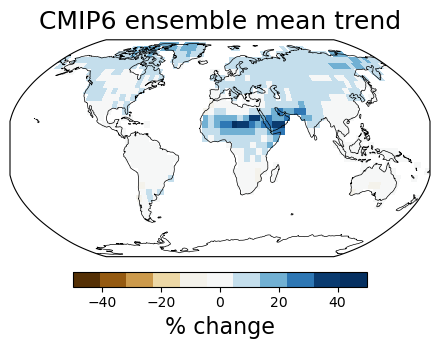

In [21]:
## create trend maps for observations
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("CMIP6 ensemble mean trend", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_std.mean(dim = "model_variant"), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/cmip6_ensemble_mean_trend_map.pdf")

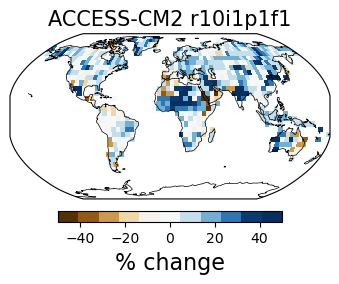

In [22]:
fig, ax = plt.subplots(1, 1, figsize = (3.5, 2.9), subplot_kw={"projection": ccrs.Robinson()})

i = 0
ax.set_title(cmip_trend_std.model_variant.values[i].replace('_', ' '), 
                 size = 15, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_std.isel(model_variant = i), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/"+cmip_trend_std.model_variant.values[i]+"_trend_map.pdf")

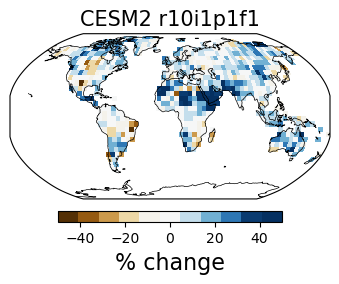

In [23]:
fig, ax = plt.subplots(1, 1, figsize = (3.5, 2.9), subplot_kw={"projection": ccrs.Robinson()})

i = 6
ax.set_title(cmip_trend_std.model_variant.values[i].replace('_', ' '), 
                 size = 15, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_std.isel(model_variant = i), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/"+cmip_trend_std.model_variant.values[i]+"_trend_map.pdf")

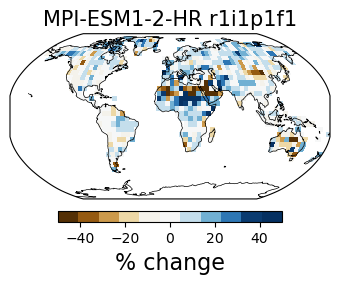

In [24]:
fig, ax = plt.subplots(1, 1, figsize = (3.5, 2.9), subplot_kw={"projection": ccrs.Robinson()})

i = 35
ax.set_title(cmip_trend_std.model_variant.values[i].replace('_', ' '), 
                 size = 15, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cmip_trend_std.isel(model_variant = i), 
             cmip_trends.lon, cmip_trends.lat, ax = ax, label = "% change", 
             CMAP = brbl, VMIN = -50, VMAX = 50)
plt.tight_layout()

plt.savefig("../figures/"+cmip_trend_std.model_variant.values[i]+"_trend_map.pdf")

In [25]:
ecdf_mon = ecdf_xr(cmip_trend_std, obs_trend_std.sel(lat = slice(-58.75, 88.75)))

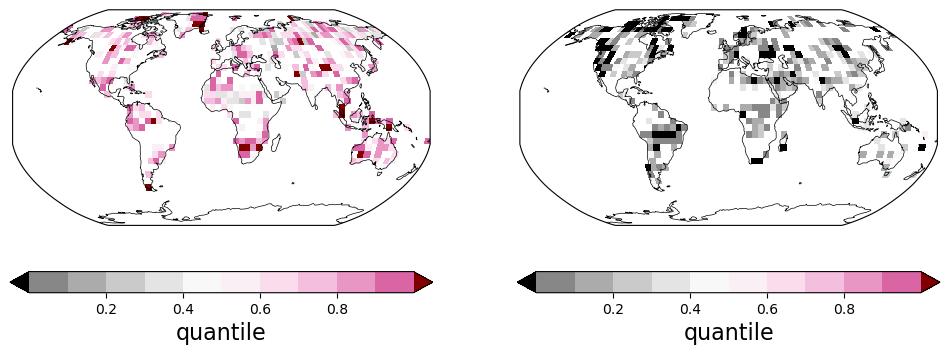

In [62]:
## create ECDF maps (subset for pos/neg trends)

fig, axes = plt.subplots(1, 2, figsize = (12, 4), subplot_kw={"projection": ccrs.Robinson()})

for ax in axes:
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

p = plot_map(xr.where(obs_trend_std.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_mon, np.nan), 
             cmip_trends.lon, cmip_trends.lat, ax = axes[0], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

p = plot_map(xr.where(obs_trend_std.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_mon, np.nan),
                      cmip_trends.lon, cmip_trends.lat, ax = axes[1], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

plt.savefig("../figures/ecdf_maps.pdf")

In [67]:
print(np.round((ecdf_mon == 1).sum().values/(obs_trend_std > 0).sum().values,4)*100, 
"% of positive trends fall outside")
print(np.round((ecdf_mon == 0).sum().values/(obs_trend_std < 0).sum().values,4)*100, 
"% of negative trends fall outside")

6.529999999999999 % of positive trends fall outside
20.91 % of negative trends fall outside


In [27]:
print("locations above cmip dist:", (ecdf_mon == 1).sum().values)
print(np.round((ecdf_mon == 1).sum().values/713,4)*100,"%")

print("locations in 97.5th percentile of dist:", (ecdf_mon >.975).sum().values)
print(np.round((ecdf_mon >0.975).sum().values/713,4)*100,"%")

print("locations below cmip dist:", (ecdf_mon == 0).sum().values)
print(np.round((ecdf_mon == 0).sum().values/713,4)*100,"%")

print("locations below 2.5th percentile of dist:", (ecdf_mon < .025).sum().values)
print(np.round((ecdf_mon <0.025).sum().values/713,4)*100,"%")

print("locations above cmip dist:", (ecdf_mon == 1).sum().values+(ecdf_mon == 0).sum().values)
print(np.round((ecdf_mon == 1).sum().values/713+(ecdf_mon == 0).sum().values/713,4)*100,"%")

print("locations in outer 5% of dist:", (ecdf_mon < .025).sum().values+(ecdf_mon > .975).sum().values)
print(np.round((ecdf_mon <0.025).sum().values/713+(ecdf_mon > .975).sum().values/713,4)*100,"%")

locations above cmip dist: 25
3.51 %
locations in 97.5th percentile of dist: 40
5.609999999999999 %
locations below cmip dist: 69
9.68 %
locations below 2.5th percentile of dist: 92
12.9 %
locations above cmip dist: 94
13.18 %
locations in outer 5% of dist: 132
18.509999999999998 %


In [28]:
ecdf_gpcp = ecdf_xr(cmip_trend_std, gpcp_trend_std.sel(lat = slice(-58.75, 88.75)))

In [29]:
print("GPCP SUMMARY:")
print("locations above cmip dist:", (ecdf_gpcp == 1).sum().values)
print(np.round((ecdf_gpcp == 1).sum().values/713,4)*100,"%")

print("locations below cmip dist:", (ecdf_gpcp == 0).sum().values)
print(np.round((ecdf_gpcp == 0).sum().values/713,4)*100,"%")

print("locations above cmip dist:", (ecdf_gpcp == 1).sum().values+(ecdf_gpcp == 0).sum().values)
print(np.round((ecdf_gpcp == 1).sum().values/713+(ecdf_gpcp == 0).sum().values/713,4)*100,"%")

GPCP SUMMARY:
locations above cmip dist: 26
3.65 %
locations below cmip dist: 59
8.27 %
locations above cmip dist: 85
11.92 %


In [30]:
ecdf_test = []
ecdf_sum_test = []
ecdf_1_test = []
ecdf_0_test = []
pos_trend_test = []
for mv in cmip_trend_std.model_variant:
    x = ecdf_xr(cmip_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value, 
                        cmip_trends.sel(predictions = "coeff").sel(model_variant = mv).value)
    ecdf_test.append(x)
    ecdf_sum_test.append([(x == 1).sum().values + (x == 0).sum().values])
    ecdf_1_test.append([(x == 1).sum().values])
    ecdf_0_test.append([(x == 0).sum().values])
    pos_trend_test.append([(cmip_trend_std.sel(model_variant = mv) > 0).sum()])
    

/tmp/ipykernel_73618/952557043.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/952557043.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/952557043.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/952557043.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; usin

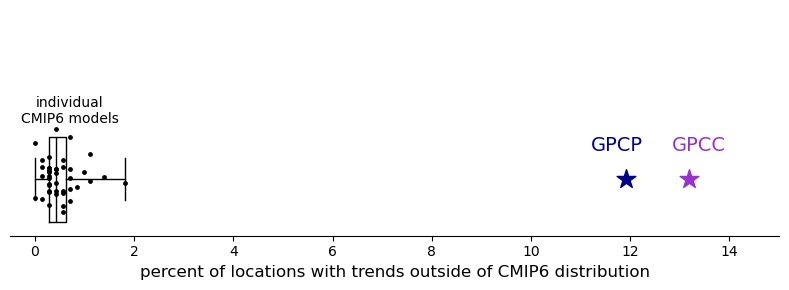

In [102]:
fig, ax = plt.subplots(figsize = (8, 3))

box = ax.boxplot(np.concat(ecdf_1_test)/713*100+np.concat(ecdf_0_test)/713*100, vert=False, whis = (0,100))
ax.scatter((ecdf_mon == 1).sum().values/713*100+(ecdf_mon == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkorchid")
ax.scatter((ecdf_gpcp == 1).sum().values/713*100+(ecdf_gpcp == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkblue")
ax.text((ecdf_gpcp == 1).sum().values/713*100+(ecdf_gpcp == 0).sum().values/713*100-0.2, 1.05, 
        "GPCP", color = "darkblue", ha = "center", size = 14)
ax.text((ecdf_mon == 1).sum().values/713*100+(ecdf_mon == 0).sum().values/713*100+0.2, 1.05, 
        "GPCC", color = "darkorchid", ha = "center", size = 14)
ax.text(0.7, 1.1, "individual\nCMIP6 models", color = "black", ha = "center")
ax.set(ylim = (0.9, 1.3), xlim = (-0.005*100, 0.15*100))
ax.set_xlabel("percent of locations with trends outside of CMIP6 distribution", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False)# ticks along the top edge are off)

x = np.random.normal(1, 0.03, size=len(ecdf_1_test))  # Add slight jitter
ax.scatter(np.concat(ecdf_1_test)/713*100+np.concat(ecdf_0_test)/713*100, x, s=6, color='black')

plt.tight_layout()
box['medians'][0].set_color('black')  # Change to the desired color
plt.savefig("../figures/monthly_frequency_test.pdf")

In [32]:
ecdf_mon.sel(lat = k, lon = j, method = "nearest")

<xarray.DataArray ()> Size: 8B
array(0.79069767)
Coordinates:
    lat          float64 8B 52.5
    lon          float64 8B 12.5
    predictions  <U13 52B 'coeff'
    quantile     float64 8B 0.95

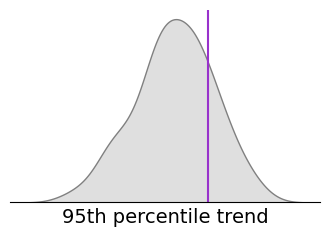

In [57]:
fig, ax = plt.subplots(figsize = (4,2.5))

k = 50
j = 10
sns.kdeplot(cmip_trend_std.sel(lat = k, lon = j, method = "nearest"), color = "gray", fill = "lightgray")
ax.axvline(obs_trend_std.sel(lat = k, lon = j, method = "nearest"), color = "darkorchid")
ax.set(ylabel = "")
ax.set_xlabel("95th percentile trend", fontsize = 14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='both',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False,# ticks along the top edge are off
    labelbottom=False)

plt.savefig("../figures/ecdf_examples.pdf")

In [58]:
ecdf_mon.sel(lat = k, lon = j, method = "nearest")

<xarray.DataArray ()> Size: 8B
array(0.79069767)
Coordinates:
    lat          float64 8B 52.5
    lon          float64 8B 12.5
    predictions  <U13 52B 'coeff'
    quantile     float64 8B 0.95

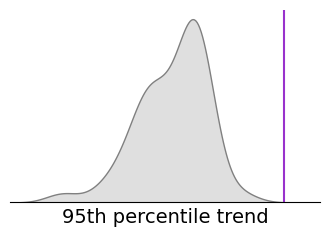

In [55]:
fig, ax = plt.subplots(figsize = (4,2.5))
k = -25
j = 15
sns.kdeplot(cmip_trend_std.sel(lat = k, lon = j, method = "nearest"), color = "gray", fill = "lightgray")
ax.axvline(obs_trend_std.sel(lat = k, lon = j, method = "nearest"), color = "darkorchid")
ax.set(xlim = (-80, 80), ylabel = "")
ax.set_xlabel("95th percentile trend", fontsize = 14)
plt.tick_params(
    axis='both',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False,# ticks along the top edge are off
    labelbottom=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.savefig("../figures/ecdf1_example.pdf")

### Compare time periods

In [35]:
def calc_ecdf(start, ens = "full"):
    end = start+39
    trend = xr.open_dataset("../processed_data/gpcc_trends/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_p095_trend.nc")
    stat = xr.open_dataset("../processed_data/gpcc_stats/gpcc_mon_"+str(start)+"-"+str(end)+"_5x5_stats.nc")
    trend_sd = (trend.sel(predictions = "coeff").value*(end-start+1))/stat.p95*100

    files = sorted(glob.glob("../processed_data/cmip_trends/pr_mon_*5x5_"+str(start)+"-"+str(end)+"_p095_trend.nc"))
    mtrend = []
    for f in files:
        mtrend.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
    mtrend = xr.concat(mtrend, dim = "model_variant")

    files = sorted(glob.glob("../processed_data/cmip_stats/pr_mon_*_5x5_"+str(start)+"-"+str(start+39)+"_stats.nc"))
    mstat = []
    for f in files:
        mstat.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
    mstat = xr.concat(mstat, dim = "model_variant")

    mtrend_sd = (mtrend.sel(predictions = "coeff").value*(end-start+1))/mstat.p95*100

    if ens == "full":
        ecdf_dat = ecdf_xr(mtrend_sd, 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))
    elif ens == "sub": 
        ecdf_dat = ecdf_xr(mtrend_sd.sel(model_variant = onevar_model_keys), 
                           trend_sd.sel(lat = slice(-58.75, 88.75)))

    ## number of positive trends (in each time period)
    summary_dat = pd.DataFrame({"start_year": [start], 
                                "pos_trends": (trend_sd > 0).sum().values,
                                "neg_trends": (trend_sd < 0).sum().values, 
                                "ecdf_1": ((trend_sd > 0) & (ecdf_dat == 1)).sum().values,
                                "ecdf_97.5": ((trend_sd > 0) & (ecdf_dat >= 0.975)).sum().values,
                                "ecdf_0": ((trend_sd < 0) & (ecdf_dat == 0)).sum().values,
                                "ecdf_025": ((trend_sd < 0) & (ecdf_dat <= 0.025)).sum().values, 
                                "ens_mean_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).mean(dim = "model_variant").values,
                                "ens_max_pos": (mtrend_sd > 0).sum(dim = ["lat", "lon"]).max(dim = "model_variant").values,
                                "ens_min_pos":(mtrend_sd > 0).sum(dim = ["lat", "lon"]).min(dim = "model_variant").values})

    return(ecdf_dat, summary_dat)

In [69]:
ecdf_alldates = []
summary_dat = []
for s in np.arange(1930, 1985, 5):
    a, b = calc_ecdf(s, ens = "sub")
    ecdf_alldates.append(a.assign_coords({"start_year": s}))
    summary_dat.append(b)

ecdf_alldates = xr.concat(ecdf_alldates, dim = "start_year")
summary_dat = pd.concat(summary_dat)

In [70]:
summary_dat

,start_year,pos_trends,neg_trends,ecdf_1,ecdf_97.5,ecdf_0,ecdf_025,ens_mean_pos,ens_max_pos,ens_min_pos
0,1930,473,240,91,137,15,24,321.547059,431,203
0,1935,426,287,88,128,17,22,313.279412,440,198
0,1940,418,295,85,129,22,45,312.170588,410,169
0,1945,416,297,65,114,29,53,317.720588,425,206
0,1950,368,345,53,76,38,62,341.317647,460,190
0,1955,363,350,40,64,40,68,363.785294,478,235
0,1960,373,340,27,46,49,71,401.782353,528,262
0,1965,350,363,32,47,64,85,437.550000,550,271
0,1970,388,325,17,37,60,90,462.466667,573,283
0,1975,389,324,24,37,49,77,474.005128,584,298


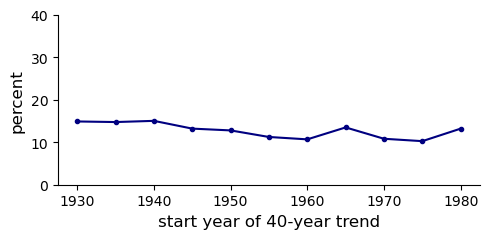

In [106]:
fig, ax = plt.subplots(figsize = (5, 2.5))

ax.plot(summary_dat.start_year, 
        (summary_dat.ecdf_1 + summary_dat.ecdf_0)/713*100, 
        marker = ".", color = "navy")

ax.set(ylim = (0,40))
ax.set_ylabel("percent", fontsize = 12)
ax.set_xlabel("start year of 40-year trend", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/timeseries.pdf")

### Daily

In [217]:
daily_sim_table = pd.read_csv("../processed_data/simulation_table_day_pr.csv")
daily_sim_table = daily_sim_table[(daily_sim_table['start_date'] <= "1930-01") & (daily_sim_table['end_date'] >= "2019-12")]
daily_sim_table_onevar = daily_sim_table.sort_values("variant").groupby("model").first().reset_index()
daily_onevar_model_keys = list(daily_sim_table_onevar["model"]+"_"+daily_sim_table_onevar["variant"])

In [218]:
cpc_trend = xr.open_dataset("../processed_data/cpc_trends/cpc_day_1980-2023_5x5_p099_trend.nc")
cpc_stat = xr.open_dataset("../processed_data/cpc_stats/cpc_day_1980-2023_5x5_stats.nc")
cpc_trend_std = (cpc_trend.sel(predictions = "coeff").value*44)/cpc_stat.p99*100

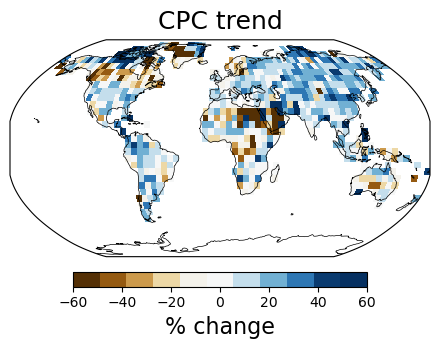

In [219]:
## create trend maps for observations
fig, ax = plt.subplots(1, 1, figsize = (4.5, 3.6), subplot_kw={"projection": ccrs.Robinson()})

ax.set_title("CPC trend", size = 18, y = 1.05, transform = ax.transAxes)
ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
p = plot_map(cpc_trend_std, 
             cpc_trend.lon,cpc_trend.lat, ax, label = "% change", 
             CMAP = brbl, VMIN = -60, VMAX = 60)
plt.tight_layout()

plt.savefig("../figures/cpc_trend_map.pdf")

In [220]:
print("CPC positive trends:", np.round((cpc_trend_std > 0).sum().values/713,4)*100, "%")

CPC positive trends: 63.11 %


In [221]:
cmip_files = sorted(glob.glob("../processed_data/cmip_trends/pr_day_*5x5_1980-2023_p099_trend.nc"))
cmip_day_trends = []
for f in cmip_files:
    cmip_day_trends.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))

cmip_day_trends = xr.concat(cmip_day_trends, dim = "model_variant")

In [222]:
cmip_day_trends

<xarray.Dataset> Size: 3MB
Dimensions:        (model_variant: 32, lat: 30, lon: 72, predictions: 5)
Coordinates:
  * lat            (lat) float64 240B -57.5 -52.5 -47.5 -42.5 ... 77.5 82.5 87.5
  * lon            (lon) float64 576B 2.5 7.5 12.5 17.5 ... 347.5 352.5 357.5
  * predictions    (predictions) <U13 260B 'coeff' ... 'coeff_ci_high'
  * model_variant  (model_variant) <U25 3kB 'ACCESS-CM2_r10i1p1f1' ... 'TaiES...
Data variables:
    value          (model_variant, lat, lon, predictions) float64 3MB nan ......

In [223]:
files = sorted(glob.glob("../processed_data/cmip_stats/pr_day_*_5x5_1980-2023_stats.nc"))
cmip_day_stat = []
for f in files:
    cmip_day_stat.append(xr.open_dataset(f).assign_coords({"model_variant": f.split("/")[-1].split("_")[2]+"_"+\
                                                f.split("/")[-1].split("_")[5]}))
cmip_day_stat = xr.concat(cmip_day_stat, dim = "model_variant")

In [224]:
cmip_day_trend_std = (cmip_day_trends.sel(predictions = "coeff").value*44)/cmip_day_stat.p99*100


In [225]:
ecdf_cpc = ecdf_xr(cmip_day_trend_std, cpc_trend_std.sel(lat = slice(-58.75, 88.75)))

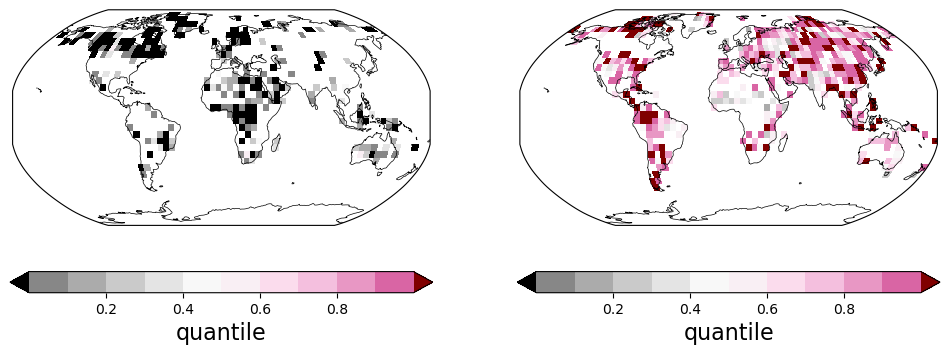

In [226]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4), subplot_kw={"projection": ccrs.Robinson()})

for ax in axes:
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())

p = plot_map(xr.where(cpc_trend_std.sel(lat = slice(-58.75, 88.75)) > 0, ecdf_cpc, np.nan), 
             cmip_trends.lon, cmip_trends.lat, ax = axes[1], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

p = plot_map(xr.where(cpc_trend_std.sel(lat = slice(-58.75, 88.75)) < 0, ecdf_cpc, np.nan),
                      cmip_trends.lon, cmip_trends.lat, ax = axes[0], label = "quantile", 
         CMAP = pugy, VMIN = 0.001, VMAX = 0.999, legend = False)
p.cmap.set_over("maroon")
p.cmap.set_under('black')
cb = plt.colorbar(p, location = "bottom", extend = "both")
cb.set_label(label="quantile",size = 16)

plt.savefig("../figures/ecdf_maps_daily.pdf")

In [227]:
print(np.round((ecdf_cpc == 1).sum().values/(cpc_trend_std > 0).sum().values,4)*100, 
"% of positive trends fall outside")
print(np.round((ecdf_cpc == 0).sum().values/(cpc_trend_std < 0).sum().values,4)*100, 
"% of negative trends fall outside")

22.0 % of positive trends fall outside
48.29 % of negative trends fall outside


In [228]:
print("locations outside cmip dist:", (ecdf_cpc == 1).sum().values+(ecdf_cpc == 0).sum().values)
print(np.round((ecdf_cpc == 1).sum().values/713+(ecdf_cpc == 0).sum().values/713,4)*100,"%")

locations outside cmip dist: 226
31.7 %


In [229]:
day_ecdf_test = []
day_ecdf_sum_test = []
day_ecdf_1_test = []
day_ecdf_0_test = []
day_pos_trend_test = []
for mv in cmip_day_trend_std.model_variant:
    x = ecdf_xr(cmip_day_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value, 
                        cmip_day_trends.sel(predictions = "coeff").sel(model_variant = mv).value)
    day_ecdf_test.append(x)
    day_ecdf_sum_test.append([(x == 1).sum().values + (x == 0).sum().values])
    day_ecdf_1_test.append([(x == 1).sum().values])
    day_ecdf_0_test.append([(x == 0).sum().values])
    day_pos_trend_test.append([(cmip_day_trend_std.sel(model_variant = mv) > 0).sum()])
    

/tmp/ipykernel_73618/571437852.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_day_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/571437852.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_day_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/571437852.py:7: DeprecationWarning: dropping labels using list-like labels is deprecated; using dict-like arguments with `drop_sel`, e.g. `ds.drop_sel(dim=[labels]).
  x = ecdf_xr(cmip_day_trends.sel(predictions = "coeff").drop(labels = mv.values, dim = "model_variant").value,
/tmp/ipykernel_73618/571437852.py:7: DeprecationWarning: dropping labels using list-like labels is depr

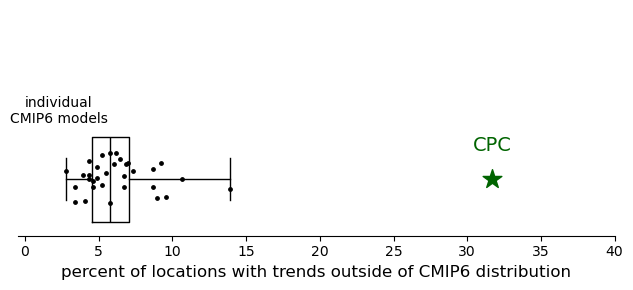

In [230]:
fig, ax = plt.subplots(figsize = (6.5, 3))

box = ax.boxplot(np.concat(day_ecdf_1_test)/713*100+np.concat(day_ecdf_0_test)/713*100, vert=False, whis = (0,100))
ax.scatter((ecdf_cpc == 1).sum().values/713*100+(ecdf_cpc == 0).sum().values/713*100, 1, 
           marker = "*", s = 200, color = "darkgreen")
ax.text((ecdf_cpc == 1).sum().values/713*100+(ecdf_cpc == 0).sum().values/713*100, 1.05, 
        "CPC", color = "darkgreen", ha = "center", size = 14)
ax.text(2.3, 1.1, "individual\nCMIP6 models", color = "black", ha = "center")
ax.set(ylim = (0.9, 1.3), xlim = (-0.005*100, 0.4*100))
ax.set_xlabel("percent of locations with trends outside of CMIP6 distribution", fontsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected      # ticks along the bottom edge are off
    top=False,  
    left=False, labelleft=False)# ticks along the top edge are off)

x = np.random.normal(1, 0.025, size=len(day_ecdf_1_test))  # Add slight jitter
ax.scatter(np.concat(day_ecdf_1_test)/713*100+np.concat(day_ecdf_0_test)/713*100, x, s=6, color='black')

plt.tight_layout()
box['medians'][0].set_color('black')  # Change to the desired color
plt.savefig("../figures/daily_frequency_test.pdf")

In [155]:
set(daily_onevar_model_keys).intersection(cmip_day_stat.model_variant.values)

{np.str_('ACCESS-CM2_r10i1p1f1'),
 np.str_('ACCESS-ESM1-5_r10i1p1f1'),
 np.str_('BCC-CSM2-MR_r1i1p1f1'),
 np.str_('CAMS-CSM1-0_r2i1p1f1'),
 np.str_('CESM2-WACCM_r1i1p1f1'),
 np.str_('CESM2_r11i1p1f1'),
 np.str_('CMCC-CM2-SR5_r1i1p1f1'),
 np.str_('CMCC-ESM2_r1i1p1f1'),
 np.str_('CNRM-CM6-1-HR_r1i1p1f2'),
 np.str_('CNRM-CM6-1_r1i1p1f2'),
 np.str_('CNRM-ESM2-1_r1i1p1f2'),
 np.str_('CanESM5_r10i1p1f1'),
 np.str_('E3SM-1-0_r1i1p1f1'),
 np.str_('EC-Earth3-Veg-LR_r1i1p1f1'),
 np.str_('EC-Earth3-Veg_r10i1p1f1'),
 np.str_('EC-Earth3_r11i1p1f1'),
 np.str_('FGOALS-g3_r1i1p1f1'),
 np.str_('GFDL-CM4_r1i1p1f1'),
 np.str_('IITM-ESM_r1i1p1f1'),
 np.str_('INM-CM4-8_r1i1p1f1'),
 np.str_('INM-CM5-0_r1i1p1f1'),
 np.str_('IPSL-CM6A-LR_r14i1p1f1'),
 np.str_('KIOST-ESM_r1i1p1f1'),
 np.str_('MIROC-ES2L_r10i1p1f2'),
 np.str_('MIROC6_r10i1p1f1'),
 np.str_('MPI-ESM1-2-HR_r1i1p1f1'),
 np.str_('MPI-ESM1-2-LR_r10i1p1f1'),
 np.str_('MRI-ESM2-0_r1i1p1f1'),
 np.str_('NESM3_r1i1p1f1'),
 np.str_('NorESM2-LM_r1i1p1f1'),
